# **Loading datasets and first-sight analysis for making the merge**

In [1]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np, seaborn as sns

odds_df = pd.read_csv('../data/UFC_betting_odds.csv')
main_df = pd.read_csv('../data/df_fights.csv')

print(odds_df.shape)
print(main_df.shape)

odds_df

(92112, 17)
(8367, 77)


,fight_url,fighter_1_url,fighter_2_url,fighter_1,fighter_2,odds_1,odds_2,f1_ko_odds,f2_ko_odds,f1_sub_odds,f2_sub_odds,f1_dec_odds,f2_dec_odds,event_date,adding_date,source,region
0,http://ufcstats.com/fight-details/d215c4e6dc13...,http://ufcstats.com/fighter-details/1eacf73d6a...,http://ufcstats.com/fighter-details/f0abbb6f34...,Cheick Kongo,Paul Buentello,1.289855,4.15,NaN,NaN,NaN,NaN,NaN,NaN,2010-03-21,2025-07-27 09:10:07.798897+00:00,zewnetrzne,us
1,http://ufcstats.com/fight-details/a41be3373678...,http://ufcstats.com/fighter-details/236a37d96d...,http://ufcstats.com/fighter-details/60c72f7459...,Mike Pierce,Julio Paulino,1.238095,4.35,NaN,NaN,NaN,NaN,NaN,NaN,2010-03-21,2025-07-27 09:10:07.798897+00:00,zewnetrzne,us
2,http://ufcstats.com/fight-details/7aa7b0c5706a...,http://ufcstats.com/fighter-details/63def5a566...,http://ufcstats.com/fighter-details/270b89c00e...,Junior Dos Santos,Gabriel Gonzaga,1.400000,3.30,NaN,NaN,NaN,NaN,NaN,NaN,2010-03-21,2025-07-27 09:10:07.798897+00:00,zewnetrzne,us
3,http://ufcstats.com/fight-details/275c22a93bdd...,http://ufcstats.com/fighter-details/7f955f71fa...,http://ufcstats.com/fighter-details/a7f4d0902b...,Alessio Sakara,James Irvin,1.833333,2.00,NaN,NaN,NaN,NaN,NaN,NaN,2010-03-21,2025-07-27 09:10:07.798897+00:00,zewnetrzne,us
4,http://ufcstats.com/fight-details/f63a647b7435...,http://ufcstats.com/fighter-details/84ac950d4c...,http://ufcstats.com/fighter-details/92a9aa9c93...,Duane Ludwig,Darren Elkins,1.645161,2.35,NaN,NaN,NaN,NaN,NaN,NaN,2010-03-21,2025-07-27 09:10:07.798897+00:00,zewnetrzne,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92107,NaN,NaN,NaN,Natalia Silva,Valentina Shevchenko,1.700000,2.22,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-01,2025-10-11T23:00:33Z,BetOnline.ag,us
92108,NaN,NaN,NaN,Alex Pereira,Carlos Ulberg,1.540000,2.60,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-14,2025-10-11T23:00:33Z,BetOnline.ag,us
92109,NaN,NaN,NaN,Alex Pereira,Jiri Prochazka,1.330000,3.50,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-14,2025-10-11T23:00:33Z,BetOnline.ag,us
92110,NaN,NaN,NaN,Alex Pereira,Jon Jones,6.000000,1.14,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-14,2025-10-11T23:00:33Z,BetOnline.ag,us


In [2]:
# Convert date columns to datetime.date for comparison
odds_df['event_date'] = pd.to_datetime(odds_df['event_date'], errors='coerce').dt.date
main_df['Date'] = pd.to_datetime(main_df['Date'], errors='coerce').dt.date

In [3]:
print(f"Number of different fights on odds_df: {odds_df[odds_df['event_date'] <= pd.to_datetime('today').date()][['fighter_1', 'fighter_2']].drop_duplicates().shape[0]}")
print(f"Number of fights on main_df after {odds_df['event_date'].min()}: {main_df[main_df['Date'] > odds_df['event_date'].min()].shape[0]}")

print(f'Difference: {main_df[main_df["Date"] > odds_df["event_date"].min()].shape[0] - odds_df[odds_df["event_date"] <= pd.to_datetime("today").date()][["fighter_1", "fighter_2"]].drop_duplicates().shape[0]} fights which appear on main_df but not on odds_df.')

Number of different fights on odds_df: 6602
Number of fights on main_df after 2010-03-21: 7007
Difference: 405 fights which appear on main_df but not on odds_df.


In [4]:
# Let's see the number of fights from odds_df which have odds information (odds_1 neither odds_2 are nulls)
print(f'Number of fights which do not have odds information: {odds_df[odds_df["odds_1"].isnull() | odds_df["odds_2"].isnull()].shape[0]}')

Number of fights which do not have odds information: 238


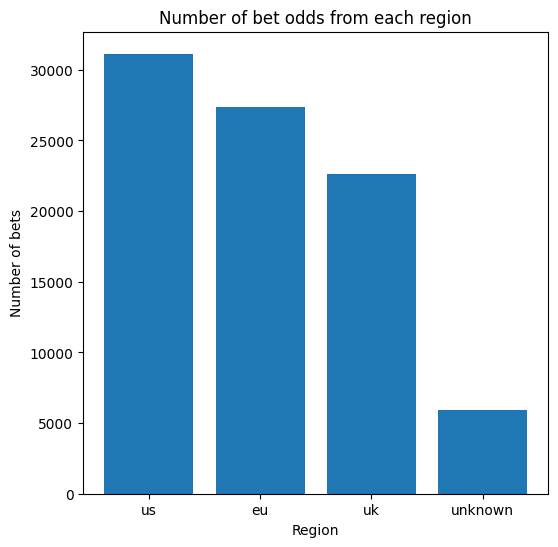

In [5]:
v = odds_df['region'].value_counts()
plt.figure(figsize = (6, 6))
plt.bar(v.index[:4], v.values[:4])
plt.title('Number of bet odds from each region')
plt.xlabel('Region')
plt.ylabel('Number of bets')
None

# **Merging fights to obtain their odds**

In [6]:
# First, we can delete main_df rows with date before the minimum date in odds_df. We can also delete future fights from odds_df.
main_df = main_df[main_df['Date'] >= odds_df['event_date'].min()]
odds_df = odds_df[odds_df['event_date'] <= pd.to_datetime('today').date()]

# Then, we need to create a common column to merge on. We will use the event_date and the fighters' names.
def normalize_id(fighterA, fighterB, date):
    names = sorted([fighterA.strip().replace(' ', '_').lower(), fighterB.strip().replace(' ', '_').lower()])
    return names[0] + '-' + names[1] + '-' + date.strftime('%Y_%m_%d')

main_df['fight_id'] = main_df.apply(lambda x: normalize_id(x['Fighter_A_Name'], x['Fighter_B_Name'], x['Date']), axis=1)

odds_df['fight_id'] = odds_df.apply(lambda x: normalize_id(x['fighter_1'], x['fighter_2'], x['event_date']), axis=1)
# In odds_df we have multiple rows for the same fight_id, so we will take the mean of the odds for each fight_id.
odds_df = odds_df.groupby('fight_id')[['odds_1', 'odds_2']].mean().reset_index()

C:\Users\juanl\AppData\Local\Temp\ipykernel_14104\400935856.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  odds_df['fight_id'] = odds_df.apply(lambda x: normalize_id(x['fighter_1'], x['fighter_2'], x['event_date']), axis=1)


In [7]:
main_df.head()

,Fighter_A_Name,Fighter_B_Name,Date,Weight_Class,Title_Bout,Referee,Location,Country,Continent,Season,...,Fighter_B_Draws,Fighter_B_Total_Fights,Fighter_B_Win_Streak,Fighter_B_Lose_Streak,Fighter_B_Experience_Years,Fighter_B_Days_Since_Last_Fight,Winner_A,Fighter_A_Is_Debut,Fighter_B_Is_Debut,fight_id
1284,James Irvin,Alessio Sakara,2010-03-21,Middleweight,0,Josh_Rosenthal,"Broomfield, Colorado, USA",USA,North America,Spring,...,0,10,2,0,4.454795,225.0,0,0,0,alessio_sakara-james_irvin-2010_03_21
1285,Paul Buentello,Cheick Kongo,2010-03-21,Heavyweight,0,Herb_Dean,"Broomfield, Colorado, USA",USA,North America,Spring,...,0,11,0,2,3.704110,99.0,0,0,0,cheick_kongo-paul_buentello-2010_03_21
1286,Brandon Vera,Jon Jones,2010-03-21,Light Heavyweight,0,Herb_Dean,"Broomfield, Colorado, USA",USA,North America,Spring,...,0,4,0,1,1.613699,106.0,0,0,0,brandon_vera-jon_jones-2010_03_21
1287,Junior Dos Santos,Gabriel Gonzaga,2010-03-21,Heavyweight,0,Josh_Rosenthal,"Broomfield, Colorado, USA",USA,North America,Spring,...,0,10,1,0,4.336986,204.0,1,0,0,gabriel_gonzaga-junior_dos_santos-2010_03_21
1288,Clay Guida,Shannon Gugerty,2010-03-21,Lightweight,0,Herb_Dean,"Broomfield, Colorado, USA",USA,North America,Spring,...,0,4,0,1,1.671233,127.0,1,0,0,clay_guida-shannon_gugerty-2010_03_21


In [8]:
odds_df.head()

,fight_id,odds_1,odds_2
0,aalon_cruz-spike_carlyle-2020_02_29,1.526316,2.650000
1,aalon_cruz-uros_medic-2021_03_06,1.500000,2.700000
2,aaron_phillips-gaston_bolanos-2023_04_15,2.600000,1.526316
3,aaron_phillips-jack_shore-2020_07_15,1.139860,5.750000
4,aaron_phillips-matt_hobar-2014_08_23,2.450000,1.645161


In [9]:
def should_swap(row):
    fa, fb = row['Fighter_A_Name'].strip().replace(' ', '_').lower(), row['Fighter_B_Name'].strip().replace(' ', '_').lower()
    f1, f2 = row['fight_id'].split('-')[0], row['fight_id'].split('-')[1]
    return fa != f1

# We need to merge both df to make main_df have the odds for each fight.
merged_df = pd.merge(main_df, odds_df[['fight_id', 'odds_1', 'odds_2']], on='fight_id', how='left')
merged_df['odds_A'] = merged_df.apply(lambda x: x['odds_2'] if should_swap(x) else x['odds_1'], axis=1)
merged_df['odds_B'] = merged_df.apply(lambda x: x['odds_1'] if should_swap(x) else x['odds_2'], axis=1)
merged_df = merged_df.drop(columns=['odds_1', 'odds_2'])

print(merged_df.shape)
print(f'There are {merged_df["fight_id"].nunique()} different fights')

merged_df.head()

(7018, 80)
There are 7018 different fights


,Fighter_A_Name,Fighter_B_Name,Date,Weight_Class,Title_Bout,Referee,Location,Country,Continent,Season,...,Fighter_B_Win_Streak,Fighter_B_Lose_Streak,Fighter_B_Experience_Years,Fighter_B_Days_Since_Last_Fight,Winner_A,Fighter_A_Is_Debut,Fighter_B_Is_Debut,fight_id,odds_A,odds_B
0,James Irvin,Alessio Sakara,2010-03-21,Middleweight,0,Josh_Rosenthal,"Broomfield, Colorado, USA",USA,North America,Spring,...,2,0,4.454795,225.0,0,0,0,alessio_sakara-james_irvin-2010_03_21,2.000000,1.833333
1,Paul Buentello,Cheick Kongo,2010-03-21,Heavyweight,0,Herb_Dean,"Broomfield, Colorado, USA",USA,North America,Spring,...,0,2,3.704110,99.0,0,0,0,cheick_kongo-paul_buentello-2010_03_21,4.150000,1.289855
2,Brandon Vera,Jon Jones,2010-03-21,Light Heavyweight,0,Herb_Dean,"Broomfield, Colorado, USA",USA,North America,Spring,...,0,1,1.613699,106.0,0,0,0,brandon_vera-jon_jones-2010_03_21,3.150000,1.425532
3,Junior Dos Santos,Gabriel Gonzaga,2010-03-21,Heavyweight,0,Josh_Rosenthal,"Broomfield, Colorado, USA",USA,North America,Spring,...,1,0,4.336986,204.0,1,0,0,gabriel_gonzaga-junior_dos_santos-2010_03_21,3.300000,1.400000
4,Clay Guida,Shannon Gugerty,2010-03-21,Lightweight,0,Herb_Dean,"Broomfield, Colorado, USA",USA,North America,Spring,...,0,1,1.671233,127.0,1,0,0,clay_guida-shannon_gugerty-2010_03_21,1.238095,4.350000


# **EDA**

In [10]:
d = merged_df
n = d[d["odds_A"].isnull() | d["odds_B"].isnull()].shape[0]
print(f'{n} missing values in odds_A or odds_B, which means {np.round((n / d.shape[0]) * 100, 4)}% fights do not have odds information.')

# As we can't create the odds and it represents 10% data, we should delete those rows
d.dropna(inplace=True)

print(d.shape)
d.head()

764 missing values in odds_A or odds_B, which means 10.8863% fights do not have odds information.
(6254, 80)


,Fighter_A_Name,Fighter_B_Name,Date,Weight_Class,Title_Bout,Referee,Location,Country,Continent,Season,...,Fighter_B_Win_Streak,Fighter_B_Lose_Streak,Fighter_B_Experience_Years,Fighter_B_Days_Since_Last_Fight,Winner_A,Fighter_A_Is_Debut,Fighter_B_Is_Debut,fight_id,odds_A,odds_B
0,James Irvin,Alessio Sakara,2010-03-21,Middleweight,0,Josh_Rosenthal,"Broomfield, Colorado, USA",USA,North America,Spring,...,2,0,4.454795,225.0,0,0,0,alessio_sakara-james_irvin-2010_03_21,2.000000,1.833333
1,Paul Buentello,Cheick Kongo,2010-03-21,Heavyweight,0,Herb_Dean,"Broomfield, Colorado, USA",USA,North America,Spring,...,0,2,3.704110,99.0,0,0,0,cheick_kongo-paul_buentello-2010_03_21,4.150000,1.289855
2,Brandon Vera,Jon Jones,2010-03-21,Light Heavyweight,0,Herb_Dean,"Broomfield, Colorado, USA",USA,North America,Spring,...,0,1,1.613699,106.0,0,0,0,brandon_vera-jon_jones-2010_03_21,3.150000,1.425532
3,Junior Dos Santos,Gabriel Gonzaga,2010-03-21,Heavyweight,0,Josh_Rosenthal,"Broomfield, Colorado, USA",USA,North America,Spring,...,1,0,4.336986,204.0,1,0,0,gabriel_gonzaga-junior_dos_santos-2010_03_21,3.300000,1.400000
4,Clay Guida,Shannon Gugerty,2010-03-21,Lightweight,0,Herb_Dean,"Broomfield, Colorado, USA",USA,North America,Spring,...,0,1,1.671233,127.0,1,0,0,clay_guida-shannon_gugerty-2010_03_21,1.238095,4.350000


In [11]:
d.sort_values('Date', inplace=True)
d.reset_index(drop=True, inplace=True)

d.to_csv('../data/df_fights_with_odds.csv', index=False)

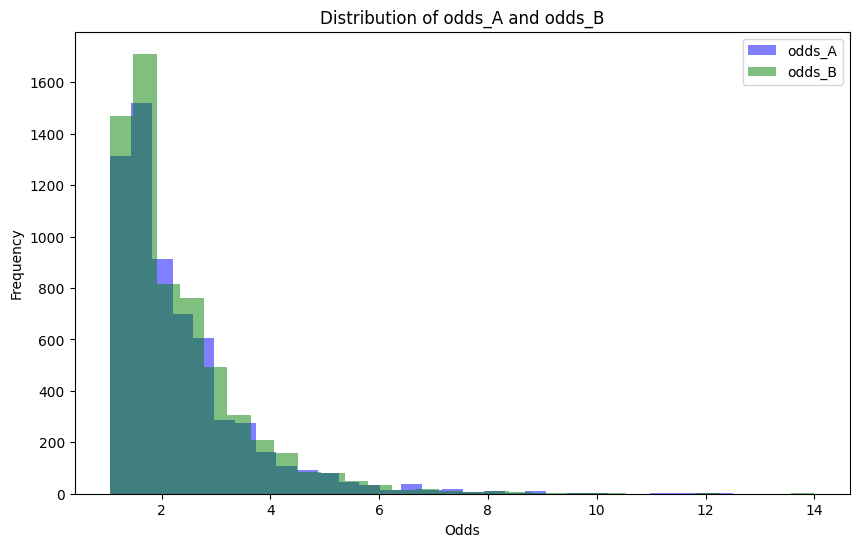

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(d['odds_A'], bins=30, alpha=0.5, color='blue', label='odds_A')
plt.hist(d['odds_B'], bins=30, alpha=0.5, color='green', label='odds_B')
plt.title('Distribution of odds_A and odds_B')
plt.xlabel('Odds')
plt.ylabel('Frequency')
plt.legend()
None

Correlation between odds_A and odds_B: -0.605460172935042


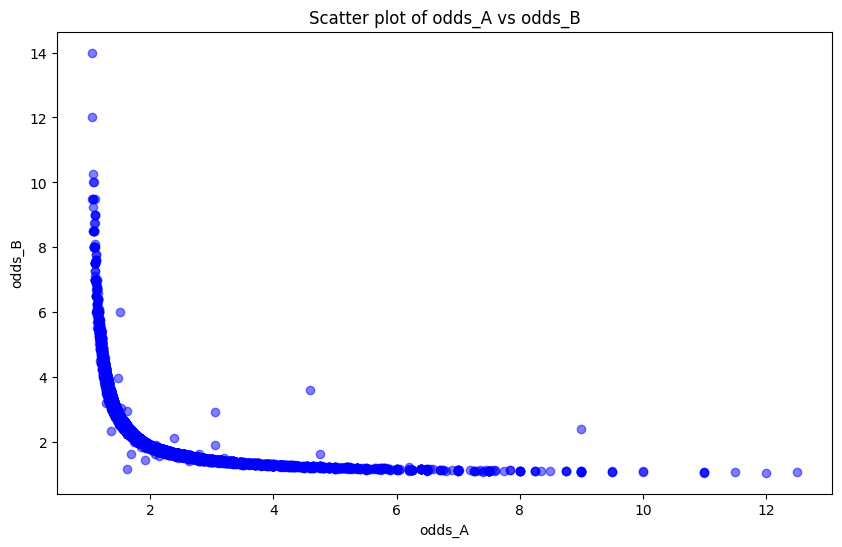

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(d['odds_A'], d['odds_B'], color='blue', alpha=0.5)
plt.title('Scatter plot of odds_A vs odds_B')
plt.xlabel('odds_A')
plt.ylabel('odds_B')
print(f'Correlation between odds_A and odds_B: {d["odds_A"].corr(d["odds_B"])}')
None


# **Creating and optimizng model with Walk-forward**

In [14]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score, confusion_matrix
import xgboost as xgb

# Ensure we have correct date data and setting up walk-forward validation
d['Date'] = pd.to_datetime(d['Date'])
d = d.sort_values(by='Date')

window_years = 2
test_years = 1

start_year = d['Date'].dt.year.min()
end_year = d['Date'].dt.year.max()

# Prepare data for modeling
X = d.select_dtypes(include=[np.number]).drop('Winner_A', axis=1)
y = d['Winner_A']

best_param = {
    'eval_metric': 'logloss',
    'colsample_bytree': 1.0,
    'learning_rate': 0.01,
    'max_depth': 4,
    'n_estimators': 100,
    'subsample': 0.8,
    'random_state': 42,
    'n_jobs': -1,

}

result, accuracies, probabilities = [], [], []
for year in range(start_year + window_years, end_year - test_years + 1):
    train_mask = (d['Date'].dt.year >= year - window_years) & (d['Date'].dt.year < year)
    test_mask = (d['Date'].dt.year >= year) & (d['Date'].dt.year < year + test_years)
    
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    x = xgb.XGBClassifier(objective='binary:logistic', **best_param)

    x.fit(X_train, y_train)
    
    y_pred = x.predict(X_test)
    y_pred_proba = x.predict_proba(X_test)[:, 1]
    
    a = accuracy_score(y_test, y_pred)
    
    print(f"Training set from {d[train_mask]['Date'].min().date()} to {d[train_mask]['Date'].max().date()} ({len(X_train)} samples)")
    print(f"Testing set from {d[test_mask]['Date'].min().date()} to {d[test_mask]['Date'].max().date()} ({len(X_test)} samples)")
    print(f"Accuracy: {a}\n")
    result.append({
        'year': year,
        'accuracy': a,
        'brier_score': brier_score_loss(y_test, y_pred_proba),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    })
    
    accuracies.append(a)
    probabilities.append(y_pred_proba)

results_df = pd.DataFrame(result)

results_df

results_df.to_csv('walkforward_results.csv', index=False)

Training set from 2010-03-21 to 2011-12-30 (490 samples)
Testing set from 2012-01-14 to 2012-12-29 (325 samples)
Accuracy: 0.5046153846153846

Training set from 2011-01-01 to 2012-12-29 (609 samples)
Testing set from 2013-01-19 to 2013-12-28 (359 samples)
Accuracy: 0.5459610027855153

Training set from 2012-01-14 to 2013-12-28 (684 samples)
Testing set from 2014-01-04 to 2014-12-20 (469 samples)
Accuracy: 0.55863539445629

Training set from 2013-01-19 to 2014-12-20 (828 samples)
Testing set from 2015-01-03 to 2015-12-19 (439 samples)
Accuracy: 0.530751708428246

Training set from 2014-01-04 to 2015-12-19 (908 samples)
Testing set from 2016-01-02 to 2016-12-30 (463 samples)
Accuracy: 0.5421166306695464

Training set from 2015-01-03 to 2016-12-30 (902 samples)
Testing set from 2017-01-15 to 2017-12-30 (418 samples)
Accuracy: 0.5311004784688995

Training set from 2016-01-02 to 2017-12-30 (881 samples)
Testing set from 2018-01-14 to 2018-12-29 (451 samples)
Accuracy: 0.5698447893569845

Tr

Best accuracy is 58.1731%


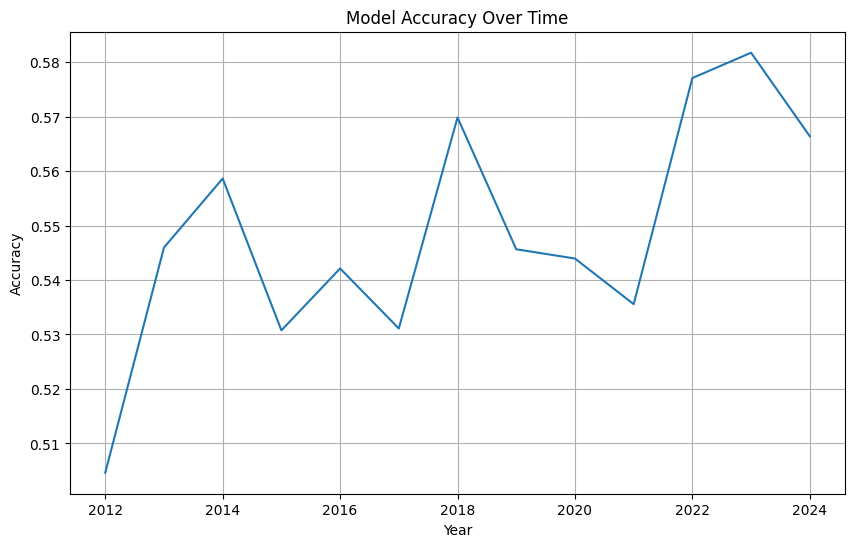

In [15]:
print(f'Best accuracy is {np.round(results_df["accuracy"].max() * 100, 4)}%')

plt.figure(figsize=(10, 6))
plt.plot(results_df['year'], results_df['accuracy'])
plt.title('Model Accuracy Over Time')
plt.xlabel('Year')
plt.ylabel('Accuracy')
plt.grid()
plt.show()
None

# **Simulation**

In [ ]:
results = d[['Fighter_A_Name', 'Fighter_B_Name', 'Date', 'odds_A', 'odds_B', 'Winner_A']].copy()
results['pred_proba_A'] = x.predict_proba(X)[:, 1]
results['pred_proba_B'] = 1 - results['pred_proba_A']
results['EV_A'] = results['pred_proba_A'] * (results['odds_A'] - 1) - results['pred_proba_B']
results['EV_B'] = (1 - results['pred_proba_A']) * (results['odds_B'] - 1) - results['pred_proba_A']

def make_bet(row, th, m):
    # Bet for a fighter X if EV_X > th and p(X) > m
    if row['EV_A'] > th and row['pred_proba_A'] > m:
        return 1
    elif row['EV_B'] > th and row['pred_proba_B'] > m:
        return 0
    return -1

def calculate_profit(initial_bankroll=100, bet_fraction=0.15):
    n_bets, wins, losses = 0, 0, 0
    invested, bankroll, profit = 0, initial_bankroll, 0

    for _, row in results.iterrows():
        if row['Bet'] == -1:
            continue
        
        n_bets += 1
        bet_amount = initial_bankroll * bet_fraction
        invested += bet_amount
        
        if (row['Bet'] == 1 and row['Winner_A'] == 1) or (row['Bet'] == 0 and row['Winner_A'] == 0):
            wins += 1
            if row['Bet'] == 1:
                winnings = bet_amount * (row['odds_A'] - 1)
            else:
                winnings = bet_amount * (row['odds_B'] - 1)
            bankroll += winnings
            profit += winnings
        else:
            losses += 1
            bankroll -= bet_amount
            profit -= bet_amount
    
    return n_bets, wins, losses, invested, profit

evaluation_results = []

for th in np.arange(0, 2.11, 0.05):
    for m in np.arange(0.35, 0.76, 0.05):
        results['Bet'] = results.apply(lambda row: make_bet(row, th, m), axis=1)
        n_bets, wins, losses, invested, profit = calculate_profit()
        evaluation_results.append((th, m, n_bets, wins, losses, invested, profit))

evaluation_df = pd.DataFrame(evaluation_results, columns=['Threshold', 'm', 'Number of Bets', 'Wins', 'Losses', 'Total Invested', 'Total Profit'])

evaluation_df['ROI (%)'] = (evaluation_df['Total Profit'] / evaluation_df['Total Invested']) * 100
evaluation_df['Win Rate (%)'] = (evaluation_df['Wins'] / evaluation_df['Number of Bets']) * 100
evaluation_df['Score (ROI * sqrt(Number of Bets))'] = evaluation_df['ROI (%)'] * np.sqrt(evaluation_df['Number of Bets'])

# pd.set_option('display.max_rows', None)
# evaluation_df

evaluation_df.to_csv('evaluation_results.csv', index=False)

In [17]:
i = evaluation_df[evaluation_df['Score (ROI * sqrt(Number of Bets))'] == evaluation_df['Score (ROI * sqrt(Number of Bets))'].max()].index

evaluation_df.loc[i]

,Threshold,m,Number of Bets,Wins,Losses,Total Invested,Total Profit,ROI (%),Win Rate (%),Score (ROI * sqrt(Number of Bets))
164,0.9,0.45,1171,690,481,17565.0,32428.144755,184.61796,58.923997,6317.603948


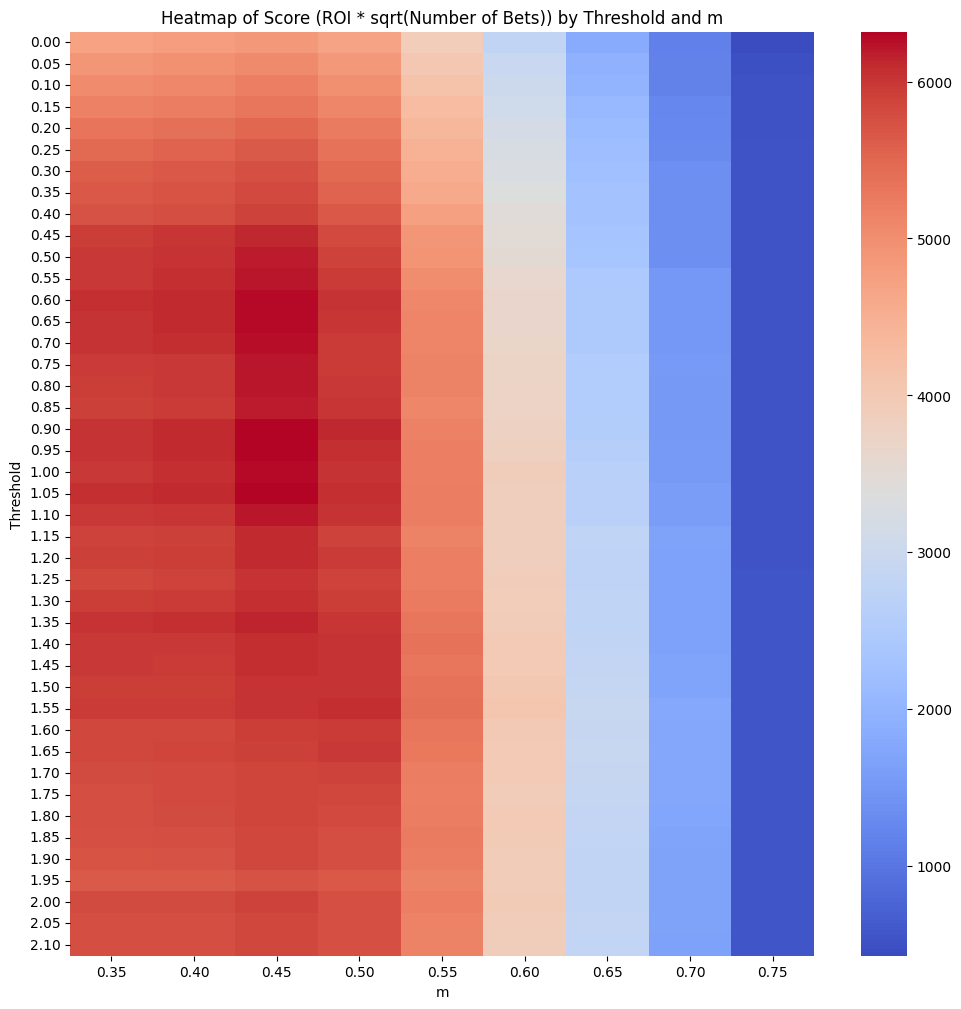

In [18]:
# Let's visualize the variable 'Score' depending on 'Threshold' and 'm'

p = evaluation_df.pivot(index='Threshold', columns='m', values='Score (ROI * sqrt(Number of Bets))')
plt.figure(figsize=(12, 12))
ax = sns.heatmap(p, annot=False, fmt=".2f", cmap='coolwarm', xticklabels=[f'{v:.2f}' for v in p.columns], yticklabels=[f'{v:.2f}' for v in p.index])
plt.title('Heatmap of Score (ROI * sqrt(Number of Bets)) by Threshold and m')
plt.xlabel('m')
plt.ylabel('Threshold')
plt.show()

## **Conclusion: The best parameters are th = 1; m = 0.5**

# **Visualize probabilities normality**

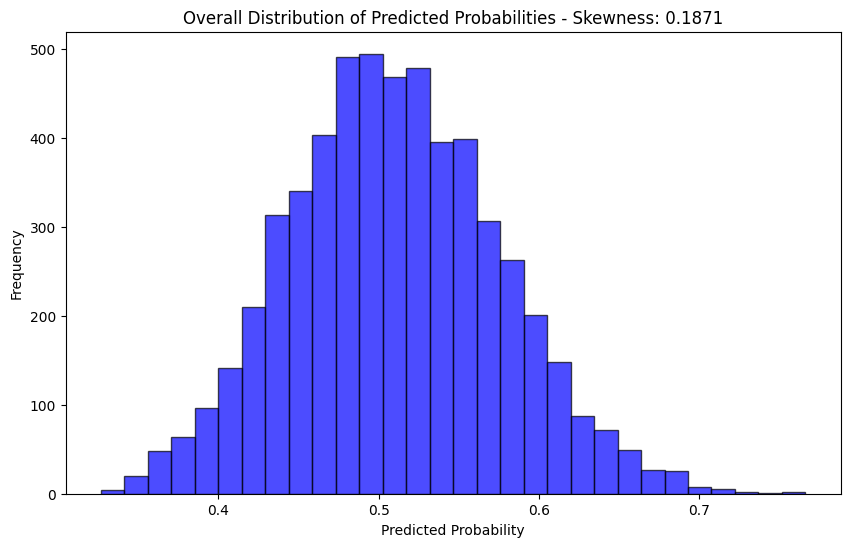

In [19]:
# The variable probabilities contains the predicted probabilities for each fold in the walk-forward validation. We can analyze the normality of these probabilities.
"""
# Plot histograms of predicted probabilities for each fold, all of them in the same matrix of plots
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(22, 14))
axes_flat = axes.flatten()

# Only plot up to the number of available axes or probabilities
n_axes = len(axes_flat)
n_probs = len(probabilities)
n_plot = min(n_axes, n_probs)

skewnesses = []

for idx in range(n_plot):
    probs, skewness = probabilities[idx], pd.Series(probabilities[idx]).skew()
    skewnesses.append(skewness)
    axes_flat[idx].hist(probs, bins=15, alpha=0.7, color='blue', edgecolor='black')
    axes_flat[idx].set_title(f'Year: {2012 + idx} - Skewness: {skewness:.4f}')
    axes_flat[idx].set_xlabel('Predicted Probability')
    axes_flat[idx].set_ylabel('Frequency')

# Hide any unused subplots
for idx in range(n_plot, n_axes):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()
"""
# Plot overall histogram of all predicted probabilities together
probabilities_total = np.concatenate(probabilities)
plt.figure(figsize=(10, 6))
plt.hist(probabilities_total, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title('Overall Distribution of Predicted Probabilities - Skewness: {:.4f}'.format(pd.Series(probabilities_total).skew()))
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.show()

# **Trying plotly**

In [20]:
import plotly.express as px
from IPython.display import HTML, display

# 'p' is the pivot table DataFrame created previously
# Add the size parameter to control the figure size
fig = px.imshow(p, 
				labels=dict(x="m", y="Threshold", color="Score (ROI * sqrt(Number of Bets))"),
				x=[f'{v:.2f}' for v in p.columns],
				y=[f'{v:.2f}' for v in p.index],
				color_continuous_scale='Viridis',
				width=800,
				height=600,
				title='Heatmap of Score (ROI * sqrt(Number of Bets)) by Threshold and m')

fig.update_layout(yaxis=dict(scaleanchor="x", scaleratio=1))  # Ensure square cells
fig.show()

In [38]:
# Single interactive figure: select metric via buttons

import plotly.graph_objects as go

metrics = ['accuracy', 'brier_score', 'roc_auc']
labels = {
    'accuracy': 'Accuracy',
    'brier_score': 'Brier Score',
    'roc_auc': 'ROC AUC'
}

default_metric = metrics[0]
fig = go.Figure(
    data=[go.Scatter(
        x=results_df['year'],
        y=results_df[default_metric],
        mode='lines+markers',
        name=labels[default_metric],
        marker=dict(size=8)
    )]
)

# Build buttons that switch the Y series and titles
buttons = []
for m in metrics:
    buttons.append(dict(
        label=labels[m],
        method='update',
        args=[
            {
                'y': [results_df[m]],
                'name': [labels[m]]
            },
            {
                'title': f"{labels[m]} Over Time",
                'yaxis': {'title': labels[m]}
            }
        ]
    ))

fig.update_layout(
    title=f"{labels[default_metric]} Over Time",
    xaxis_title='Year',
    yaxis_title=labels[default_metric],
    hovermode='x unified',
    width=1500, height=500, margin=dict(t=80, r=20, b=40, l=60),
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=1.0, xanchor='right',
        y=1.2, yanchor='top',
        pad={'r': 6, 't': 6}
    )]
)

# Optional: save a single HTML with interactive buttons
# fig.write_html('metrics_over_time.html')
fig.show()

In [40]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Build 3D surface from the seaborn heatmap data (cell 23 pivot 'p')
heatmap_data = evaluation_df.pivot(index='Threshold', columns='m', values='Score (ROI * sqrt(Number of Bets))')
# Ensure numeric, sorted axes
heatmap_data = heatmap_data.sort_index().sort_index(axis=1)
th_values = pd.to_numeric(heatmap_data.index, errors='coerce')
m_values = pd.to_numeric(heatmap_data.columns, errors='coerce')

fig = go.Figure()
fig.add_trace(go.Surface(
    z=heatmap_data.to_numpy(),
    x=m_values.to_numpy(),  # m on X axis
    y=th_values.to_numpy(), # Threshold on Y axis
    colorscale="thermal"
))

# Sizing and scene/axis formatting
fig.update_layout(
    width=1200,
    height=900,
    autosize=False,
    margin=dict(t=90, b=0, l=0, r=0),  # more top space for title
    template="plotly_white",
    title="3D Surface of Score by Threshold and m",
    scene=dict(
        xaxis=dict(title='m', tickformat='.2f'),
        yaxis=dict(title='Threshold', tickformat='.2f'),
        zaxis=dict(title='Score (ROI * sqrt(Number of Bets))')
    )
)

fig.update_scenes(
    aspectratio=dict(x=1, y=1, z=0.7),
    aspectmode="manual"
)

# Dropdown to toggle Surface/Heatmap (reuses x/y/z) - horizontal at top-right inside plot
fig.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(args=["type", "surface"], label="3D Surface", method="restyle"),
                dict(args=["type", "heatmap"], label="Heatmap", method="restyle")
            ]),
            direction="down",
            pad={"r": 6, "t": 6},
            showactive=True,
            x=0.98, xanchor="right",
            y=0.98, yanchor="top"
        )
    ],
    annotations=[
        dict(
            text="Trace type:", showarrow=False,
            x=0.72, y=0.98, yref="paper", xref="paper",
            align="center"
        )
    ]
)

fig.show()

In [42]:
# Let's plot the distribution of probabilities given by the model vs the odds-implied probabilities for the entire dataset.

# We have probabilities_total for the probabilities given by the model

# In the dataset 'd', we have odds_A and odds_B for each fight. We can compute the odds-implied probabilities as follows:

# Implied = 1 / Odds
implied_prob_A, implied_prob_B = 1 / d['odds_A'], 1 / d['odds_B']
# For the actual probability we need to normalize the implied probability as: prob = implied / (implied_A + implied_B)
prob_A, prob_B = implied_prob_A / (implied_prob_A + implied_prob_B), implied_prob_B / (implied_prob_A + implied_prob_B)

